# Model 1 — Average-embedding + similarity search
### Learning where solar is suitable from AlphaEarth embeddings

This notebook is written to be **followed end-to-end without prior knowledge** of the specific methods —
every step has an explanation of *what* it does, *why*, and *what the result means*, plus a picture.

## The big picture
We have 82,000 image "chips" covering known solar farms worldwide. Each chip is **not** an ordinary photo — it is a
**64-band AlphaEarth (AEF) embedding**: Google's AI has compressed a full year of satellite observations of each 10 m
patch of ground into a 64-number "fingerprint" that summarises what that land *is* (crops, desert, water, built-up, …).
Crucially, each chip is the embedding of the land **2 years before the solar farm was built**, so we are looking at the
*pre-existing* land. Each chip comes with a **mask** marking which pixels later became solar panels.

**Question for Model 1:** if we average the embeddings of all known solar-footprint pixels into a single "typical solar
site" fingerprint (a *prototype*), can we then find *new* solar-suitable land by measuring similarity to that prototype?
This is the classic embedding approach, and it's the first of four models.

## What this notebook contains
1. **Setup** — paths & libraries
2. **Sanity check** — look at one real site end-to-end (AEF, mask, Sentinel-2 before vs after) to prove the data lines up
3. **Are the embeddings unit-length?** — a property that decides which maths to use
4. **Train/test split** — leakage-safe and country-balanced
5. **Streaming accumulator** — how we summarise 2 TB of pixels without loading it all
6. **The prototype** — building the average solar fingerprint
7. **Scoring methods explained** — cosine, Mahalanobis, k-means (with the maths)
8. **Evaluation** — ROC-AUC & PR-AUC explained, on our real results
9. **Heatmaps** — what the model "sees" on held-out chips
10. **Findings & next steps**

> **Runtime.** Reads are disk-bound; the notebook uses a random subsample so a full top-to-bottom run is ~5 minutes on
> the `solar-siting-ml` kernel. Set `N_TRAIN_CHIPS = len(train)` in section 5 to use all training data.

## 1. Setup

We work on the JASMIN group workspace where the data lives. `chips/` holds the 64-band AEF GeoTIFFs and `masks/` holds
the matching 0/1 solar masks (same filenames). A filename like `POS_IND_10859_2017_20.tif` means:
`POS` = positive (a real solar site), `IND` = country (India), `10859` = site id, `2017` = the embedding year
(2 years pre-install), `20` = which 256×256 tile of that site.

In [1]:
import os, io, time, warnings
import numpy as np, pandas as pd, rasterio
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# Earth-observation libs for the Sentinel-2 sanity check
from rasterio.warp import transform_bounds
from sklearn.decomposition import PCA
import pystac_client, planetary_computer, odc.stac

ROOT = "/home/users/ar29/Solar_Workspace"          # -> symlink to GWS /gws/ssde/j25b/gbov/abdullah_solar
os.chdir(ROOT)
CH = "Data/aef_solar_chips/positives/chips"         # 64-band AEF embedding chips (256x256)
MK = "Data/aef_solar_chips/positives/masks"         # matching binary solar masks (256x256)
D  = 64                                             # embedding dimensionality
print("working dir:", os.getcwd())
print("chips:", len(os.listdir(CH)), "| masks:", len(os.listdir(MK)))

working dir: /gws/ssde/j25b/gbov/abdullah_solar
chips: 82148 | masks: 82148


## 2. Sanity check — one real site, end to end

Before any modelling, we confirm the data is internally consistent. For one high-solar chip we show four panels:

| panel | what it is | what to look for |
|---|---|---|
| **AEF embedding** | the 64 bands squeezed to 3 colours via PCA (false colour) | spatial structure/texture in the land |
| **solar mask** | ground-truth footprint (white = became solar) | a coherent blob, not noise |
| **Sentinel-2 "before"** | a normal RGB photo near the embedding year | *bare* land — panels not built yet |
| **Sentinel-2 "after"** | a normal RGB photo ~2 years later | the **solar farm now visible**, matching the mask |

If the mask footprint matches where panels appear in the "after" photo, then chip ↔ mask ↔ coordinates ↔ time all agree.
(Sentinel-2 is fetched live from Microsoft's Planetary Computer, which is reachable from JASMIN.)

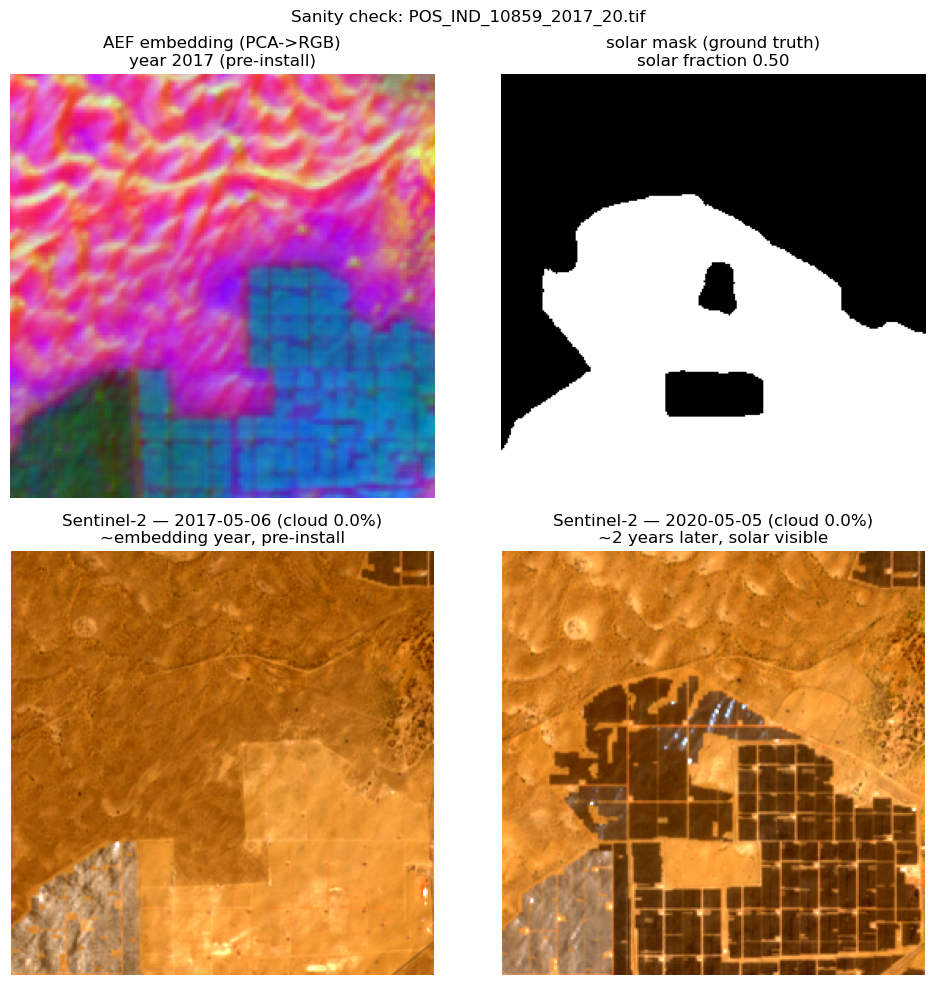

In [2]:
CAT = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1",
                                modifier=planetary_computer.sign_inplace)

def s2_rgb(bbox, year):
    # fetch the least-cloudy Sentinel-2 RGB scene overlapping `bbox` in `year` (full year = hemisphere-agnostic)
    items = []
    for date_range in [f"{year}-01-01/{year}-12-31", f"{year-1}-01-01/{year+1}-12-31"]:
        items = list(CAT.search(collections=["sentinel-2-l2a"], bbox=list(bbox),
                                datetime=date_range, query={"eo:cloud_cover": {"lt": 30}}).items())
        if items:
            break
    if not items:
        return None, "no scene", None
    items.sort(key=lambda it: it.properties["eo:cloud_cover"])          # least cloudy first
    ds = odc.stac.load(items[:1], bands=["B04", "B03", "B02"], bbox=list(bbox), resolution=10)  # R,G,B
    rgb = np.stack([ds["B04"].isel(time=0).values, ds["B03"].isel(time=0).values,
                    ds["B02"].isel(time=0).values], axis=-1).astype(float)
    lo, hi = np.nanpercentile(rgb, [2, 98])                             # contrast stretch for display
    rgb = np.clip((rgb - lo) / (hi - lo + 1e-9), 0, 1)
    return rgb, items[0].properties["datetime"][:10], round(items[0].properties["eo:cloud_cover"], 1)

SANITY_CHIP = "POS_IND_10859_2017_20.tif"           # a clear Bhadla (India) desert site; change to any chip you like

with rasterio.open(f"{CH}/{SANITY_CHIP}") as s:
    arr  = s.read().astype(np.float32)                                  # (64,256,256)
    bbox = transform_bounds(s.crs, "EPSG:4326", *s.bounds)              # chip footprint in lon/lat
with rasterio.open(f"{MK}/{SANITY_CHIP}") as m:
    msk = m.read(1)
fyear = int(SANITY_CHIP.split("_")[3])

# AEF -> RGB: PCA reduces the 64 bands to their 3 most-informative combinations, then scale to [0,1] for display
rgb = PCA(3, random_state=0).fit_transform(arr.reshape(D, -1).T)
aef_rgb = ((rgb - rgb.min(0)) / (np.ptp(rgb, 0) + 1e-9)).reshape(256, 256, 3)

s2_pre,  d_pre,  c_pre  = s2_rgb(bbox, fyear)        # ~embedding year (pre-install)
s2_post, d_post, c_post = s2_rgb(bbox, fyear + 3)    # ~2 years later (solar should be built)

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax[0,0].imshow(aef_rgb);         ax[0,0].set_title(f"AEF embedding (PCA->RGB)\nyear {fyear} (pre-install)")
ax[0,1].imshow(msk, cmap="gray");ax[0,1].set_title(f"solar mask (ground truth)\nsolar fraction {(msk>0).mean():.2f}")
if s2_pre  is not None: ax[1,0].imshow(s2_pre)
ax[1,0].set_title(f"Sentinel-2 — {d_pre} (cloud {c_pre}%)\n~embedding year, pre-install")
if s2_post is not None: ax[1,1].imshow(s2_post)
ax[1,1].set_title(f"Sentinel-2 — {d_post} (cloud {c_post}%)\n~2 years later, solar visible")
for a in ax.ravel(): a.axis("off")
plt.suptitle(f"Sanity check: {SANITY_CHIP}", fontsize=12); plt.tight_layout(); plt.show()

## 3. Are the embeddings unit-length?

A vector's **L2 norm** is its length: $\lVert v \rVert = \sqrt{v_1^2 + v_2^2 + \dots + v_{64}^2}$.
AlphaEarth is designed so each pixel's 64-number vector has length ≈ 1 — i.e. all pixels live on the surface of a
64-dimensional unit sphere. **Why we care:** if all vectors have length 1, then the natural way to compare two of them is
the **cosine of the angle** between them, which for unit vectors equals their **dot product**. We verify this below (the
histogram should be a spike at 1.0) — it tells us to use cosine similarity, and to re-normalise our prototype later.

POS_AFG_10604_2017_1.tif: shape (64, 256, 256), dtype float64
per-pixel L2 norm -> mean 1.0001, std 0.0021, min 0.9920, max 1.0088


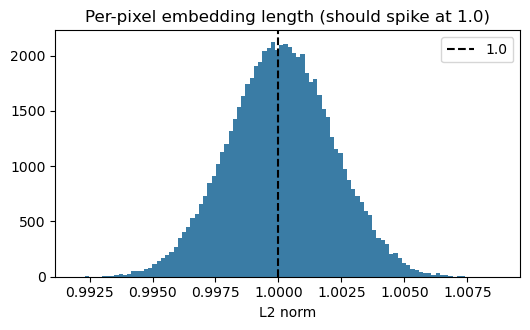

In [3]:
fn0 = sorted(os.listdir(CH))[0]
with rasterio.open(f"{CH}/{fn0}") as s:
    a = s.read().astype(np.float64)
norms = np.sqrt((a ** 2).sum(0)).ravel()            # length of every pixel's 64-vector
print(f"{fn0}: shape {a.shape}, dtype {a.dtype}")
print(f"per-pixel L2 norm -> mean {norms.mean():.4f}, std {norms.std():.4f}, "
      f"min {norms.min():.4f}, max {norms.max():.4f}")

plt.figure(figsize=(6, 3.2))
plt.hist(norms, bins=100, color="#3a7ca5"); plt.axvline(1.0, color="k", ls="--", label="1.0")
plt.title("Per-pixel embedding length (should spike at 1.0)"); plt.xlabel("L2 norm"); plt.legend(); plt.show()
# => confirmed unit-norm: use cosine = dot product; the prototype (an average) must be re-normalised to length 1.

## 4. Train / test split — leakage-safe and country-balanced

To measure honestly we hold out test data the model never sees in training. Two pitfalls we avoid:

- **Spatial leakage.** The tiles `..._1, ..._2, ...` are an *overlapping* grid over the *same* solar site. If tile 1 is in
  training and tile 2 in test, the model has effectively seen the answer. **Fix:** split whole **scenes** (a site), never
  individual tiles — every tile of a scene goes to the same side.
- **Country imbalance.** A few countries dominate the data. If the test set were random it might be mostly China. **Fix:**
  **stratify by country** — hold out ~20% of each country's scenes, so every country is proportionally represented.

We cache the result to CSV so it's identical on every rerun.

train 65,985 tiles / test 16,163 tiles | 16,053 scenes | 131 countries


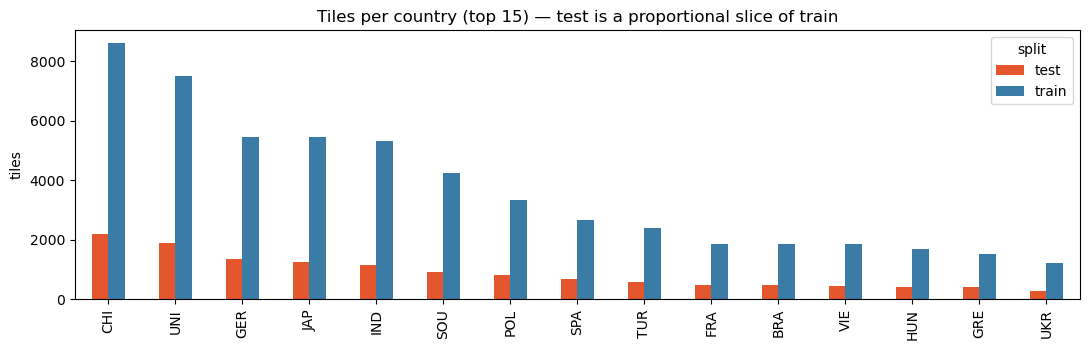

In [4]:
SPLIT = "Solar-Siting/artifacts/splits/emb_search_split.csv"
if os.path.exists(SPLIT):
    split = pd.read_csv(SPLIT)
else:
    rows = []
    for f in os.listdir(CH):
        if f.endswith(".tif"):
            p = f[:-4].split("_")                    # POS, country, siteid, year, tile
            rows.append((f, p[1], p[3] if len(p) >= 4 else "NA", "_".join(p[:-1])))
    df = pd.DataFrame(rows, columns=["chip", "country", "year", "scene"])
    scenes = df.groupby("scene").agg(country=("country", "first")).reset_index()
    rng = np.random.default_rng(42); scenes["split"] = "train"
    for _, grp in scenes.groupby("country"):         # 20% of each country's scenes -> test
        idx = rng.permutation(grp.index.to_numpy()); n = len(idx)
        if n >= 2:
            scenes.loc[idx[:max(1, min(int(round(n*0.2)), n-1))], "split"] = "test"
    df["split"] = df["scene"].map(scenes.set_index("scene")["split"])
    df.to_csv(SPLIT, index=False); split = df

train = split[split.split == "train"].reset_index(drop=True)
test  = split[split.split == "test"].reset_index(drop=True)
assert split.groupby("scene")["split"].nunique().max() == 1, "a scene leaked across splits!"
print(f"train {len(train):,} tiles / test {len(test):,} tiles | "
      f"{split['scene'].nunique():,} scenes | {split['country'].nunique()} countries")

# visual confirmation: train vs test are proportional across the biggest countries
top = split['country'].value_counts().head(15).index
ct = split[split.country.isin(top)].groupby(['country','split']).size().unstack(fill_value=0).loc[top]
ct.plot(kind='bar', figsize=(11,3.6), color={'train':'#3a7ca5','test':'#e4572e'})
plt.title("Tiles per country (top 15) — test is a proportional slice of train")
plt.ylabel("tiles"); plt.xlabel(""); plt.tight_layout(); plt.show()

## 5. Streaming accumulator — summarising 2 TB without loading it

We need the **average** solar embedding (and, later, its **covariance** — the shape of the solar cloud). We cannot load
all pixels at once, so we *stream*: read one chip at a time and keep only running totals. Two totals give us everything:

- sum of vectors  $\;S=\sum_i x_i\;$  →  mean  $\;\mu = S/n$
- sum of outer products  $\;O=\sum_i x_i x_i^\top\;$  →  covariance  $\;\Sigma = O/n - \mu\mu^\top$

These totals are tiny (64 and 64×64 numbers) no matter how many pixels we process, and the order doesn't matter. Reading
the 32 MB rasters is the slow part, so we read **many files in parallel** (threads) — about 6× faster. Each worker returns
its partial totals for solar pixels and, separately, for *background* pixels (everything not masked, kept only as a
diagnostic — see §7). We also keep a small random sample of solar pixels for k-means.

In [5]:
def _reader(fn, per_chip=12, bg_keep=0.12):
    # runs in a worker thread: read one chip+mask, return partial sums
    rng = np.random.default_rng(abs(hash(fn)) % 2**32)
    with rasterio.open(f"{CH}/{fn}") as s: arr = s.read().astype(np.float32)
    with rasterio.open(f"{MK}/{fn}") as m: msk = m.read(1) > 0
    flat = arr.reshape(D, -1); sm = msk.reshape(-1)
    S = flat[:, sm].T                                            # solar pixels: (Ns, 64)
    n = S.shape[0]
    s     = S.sum(0)   if n else np.zeros(D)                     # sum of vectors
    outer = S.T @ S    if n else np.zeros((D, D))                # sum of outer products
    res   = S[rng.choice(n, min(n, per_chip), replace=False)].copy() if n else np.zeros((0, D), np.float32)
    B = flat[:, ~sm].T                                           # background/context pixels
    B = B[rng.random(B.shape[0]) < bg_keep]                      # subsample to save memory
    bn = B.shape[0]
    bs     = B.sum(0) if bn else np.zeros(D)
    bouter = B.T @ B  if bn else np.zeros((D, D))
    return n, s, outer, bn, bs, bouter, res

def accumulate(chips, workers=8, progress_every=1000):
    a = dict(n=0, s=np.zeros(D), outer=np.zeros((D, D)),
             bn=0, bs=np.zeros(D), bouter=np.zeros((D, D)), res=[])
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=workers) as ex:
        for i, (n, s, o, bn, bs, bo, res) in enumerate(ex.map(_reader, chips), 1):
            a['n'] += n; a['s'] += s; a['outer'] += o
            a['bn'] += bn; a['bs'] += bs; a['bouter'] += bo
            if res.shape[0]: a['res'].append(res)
            if i % progress_every == 0:
                print(f"  {i}/{len(chips)}  solar_px={a['n']:,}  {time.time()-t0:.0f}s")
    a['res'] = np.concatenate(a['res']) if a['res'] else np.zeros((0, D), np.float32)
    print(f"done {len(chips)} tiles in {time.time()-t0:.0f}s | solar_px={a['n']:,}  bg_px={a['bn']:,}")
    return a

In [6]:
# The 64-dim average converges after a few million pixels, so a random subsample is plenty for Model 1.
# Full training set (~66k tiles) is ~1 h of disk reads; set N_TRAIN_CHIPS = len(train) to use everything.
N_TRAIN_CHIPS = 20000
train_sub = train.sample(N_TRAIN_CHIPS, random_state=1)
SUB = accumulate(list(train_sub.chip), workers=8, progress_every=500)

  500/20000  solar_px=461,267  106s
  1000/20000  solar_px=971,544  209s
  1500/20000  solar_px=1,505,246  315s
  2000/20000  solar_px=1,951,985  419s
  2500/20000  solar_px=2,378,593  523s
  3000/20000  solar_px=2,979,671  628s
  3500/20000  solar_px=3,432,378  732s
  4000/20000  solar_px=3,870,886  837s
  4500/20000  solar_px=4,379,935  942s
  5000/20000  solar_px=4,896,718  1048s
  5500/20000  solar_px=5,413,592  1152s
  6000/20000  solar_px=5,860,087  1255s
  6500/20000  solar_px=6,474,997  1360s
  7000/20000  solar_px=7,134,570  1464s
  7500/20000  solar_px=7,741,591  1565s
  8000/20000  solar_px=8,177,592  1667s
  8500/20000  solar_px=8,719,142  1770s
  9000/20000  solar_px=9,086,348  1872s
  9500/20000  solar_px=9,553,459  1975s
  10000/20000  solar_px=10,102,039  2078s
  10500/20000  solar_px=10,602,610  2179s
  11000/20000  solar_px=11,161,365  2280s
  11500/20000  solar_px=11,766,377  2379s
  12000/20000  solar_px=12,224,241  2478s
  12500/20000  solar_px=12,683,250  2577s
  

## 6. The prototype (average solar fingerprint)

The prototype is simply the **mean** of all solar-pixel vectors, $\mu = \frac1n\sum_i x_i$. One subtlety: the average of
many unit-length vectors is itself **shorter than 1** (arrows pointing slightly different ways partly cancel). So we
**re-normalise** it back to length 1, $\;\hat p = \mu/\lVert\mu\rVert\;$, before using cosine similarity.

Two numbers describe the solar cloud:
- $\lVert\mu\rVert$ — the **mean resultant length** (0 = pixels point everywhere, 1 = all identical). A middling value means
  solar pixels are *spread out*, not a tight cluster.
- $\cos(\mu_{\text{solar}}, \mu_{\text{background}})$ — how similar the average solar pixel is to the average surrounding
  pixel. Near 1 means solar barely differs from its surroundings — a warning sign for a similarity-only approach.

In [7]:
mu    = SUB['s'] / SUB['n']                         # mean solar embedding (length < 1)
proto = mu / np.linalg.norm(mu)                     # re-normalised prototype  <-- the Model-1 vector
C     = SUB['outer'] / SUB['n'] - np.outer(mu, mu)  # covariance = E[xx^T] - mu mu^T (shape of the solar cloud)
Cinv  = np.linalg.inv(C + 1e-3 * np.trace(C) / D * np.eye(D))   # inverse, with a small ridge for stability (see §7)
bmu   = SUB['bs'] / SUB['bn']                        # mean background/context vector (diagnostic only)

print(f"mean resultant length  ||mu|| = {np.linalg.norm(mu):.4f}   (0=spread, 1=identical)")
print(f"cos(mean_solar, mean_background) = {mu@bmu/(np.linalg.norm(mu)*np.linalg.norm(bmu)):.4f}")
np.savez("Solar-Siting/artifacts/models/emb_search_proto_sub.npz", proto=proto, mu=mu, C=C, Cinv=Cinv, bmu=bmu, n=SUB['n'])
print("saved prototype -> Solar-Siting/artifacts/models/emb_search_proto_sub.npz")

mean resultant length  ||mu|| = 0.4049   (0=spread, 1=identical)
cos(mean_solar, mean_background) = 0.8627
saved prototype -> Solar-Siting/emb_search_proto_sub.npz


## 7. Scoring methods — the maths, in plain terms

Given a new pixel $x$ (a 64-vector), how "solar-like" is it? We try three ideas.

### (a) Cosine similarity — "how aligned is it with the average solar pixel?"
$\;\text{score} = \hat p \cdot x = \cos(\text{angle between }x\text{ and the prototype}).$
Range $[-1,1]$, higher = more aligned. Simple, but treats all 64 directions as equally important.

### (b) Mahalanobis distance — "cosine that knows the *shape* of the solar cloud"
Cosine ignores that solar pixels vary **a lot** along some directions and **barely** along others. The **covariance
matrix** $\Sigma$ (the 64×64 table from §5) encodes exactly this shape. The **Mahalanobis distance**

$$d^2(x) = (x-\mu)^\top\,\Sigma^{-1}\,(x-\mu)$$

is ordinary distance *after* stretching space so the solar cloud becomes a perfect sphere ("whitening"). Being off in a
direction where solar naturally varies a lot is cheap; being off in a direction where solar is very consistent is
expensive. If $\Sigma = I$ this is just Euclidean distance. We score with $-d^2$ (closer = more solar-like).

*Why the ridge $+\epsilon I$?* On the unit sphere the cloud is flat in the radial direction (near-zero variance), which
makes $\Sigma$ impossible to invert. Adding a tiny $\epsilon I$ fixes that without changing the meaningful directions.

### (c) k-means multi-prototype — "maybe solar has sub-types"
Solar sites differ (desert utility-scale, rooftop, floating, …). k-means splits the solar pixels into $K$ clusters, each
with its own mini-prototype; we score a pixel by its **best** (max) cosine to any of them. This tests whether *one* average
is too crude.

*(A note on the "within-chip contrast" line you'll see in results: it is `solar_mean − background_mean`, a direction that
**separates** solar from its surroundings. It is a **diagnostic only** — the background here is in-scene context, not a
true "unsuitable" negative — but it hints that a **discriminative** approach beats a **similarity** one. More in §10.)*

In [8]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.cluster import MiniBatchKMeans

def eval_reader(fn, keep=0.25):
    # read a test tile, return a prevalence-preserving random subset of its pixels + labels
    rng = np.random.default_rng(abs(hash(fn)) % 2**32)
    with rasterio.open(f"{CH}/{fn}") as s: arr = s.read().astype(np.float32)
    with rasterio.open(f"{MK}/{fn}") as m: lab = (m.read(1) > 0).reshape(-1).astype(np.int8)
    X = arr.reshape(D, -1).T
    k = rng.random(X.shape[0]) < keep
    return X[k], lab[k]

test_sub = test.sample(400, random_state=2)          # 400 held-out tiles
Xe, ye = [], []
with ThreadPoolExecutor(max_workers=8) as ex:
    for X, lab in ex.map(eval_reader, list(test_sub.chip)):
        Xe.append(X); ye.append(lab)
Xe = np.concatenate(Xe); ye = np.concatenate(ye)     # Xe: pixels x 64,  ye: 0/1 solar
print(f"eval pixels {Xe.shape[0]:,} | solar prevalence {ye.mean():.4f}\n")

def score(name, s):
    print(f"  {name:34s} ROC-AUC={roc_auc_score(ye,s):.3f}  PR-AUC={average_precision_score(ye,s):.3f}")
    return s

sc_cos = score("(a) mean-cosine (Model 1)", Xe @ proto)
dt = Xe - mu
sc_mah = score("(b) Mahalanobis", -((dt @ Cinv) * dt).sum(1))
for K in [8, 16]:
    Cc = MiniBatchKMeans(K, n_init=5, random_state=0, batch_size=4096).fit(SUB['res']).cluster_centers_
    Cc = Cc / np.linalg.norm(Cc, axis=1, keepdims=True)
    score(f"(c) k-means max-cos (K={K})", (Xe @ Cc.T).max(1))
pc = mu - bmu; pc = pc / np.linalg.norm(pc)
sc_con = score("    within-chip contrast [diag]", Xe @ pc)
print(f"\n  baseline (guess prevalence) PR-AUC = {ye.mean():.3f}")

eval pixels 6,554,522 | solar prevalence 0.0184

  (a) mean-cosine (Model 1)          ROC-AUC=0.564  PR-AUC=0.022
  (b) Mahalanobis                    ROC-AUC=0.691  PR-AUC=0.031
  (c) k-means max-cos (K=8)          ROC-AUC=0.498  PR-AUC=0.019
  (c) k-means max-cos (K=16)         ROC-AUC=0.528  PR-AUC=0.019
      within-chip contrast [diag]    ROC-AUC=0.805  PR-AUC=0.076

  baseline (guess prevalence) PR-AUC = 0.018


## 8. How we measure accuracy — ROC-AUC and PR-AUC

The model outputs a **score** per pixel, not a yes/no. To grade the scores across *all* possible thresholds at once we use
two summary numbers. The left plot below (score histograms) shows the core difficulty: solar and non-solar scores overlap
almost completely.

**ROC-AUC.** Sweeping the threshold traces *True-Positive-Rate* (recall: fraction of real solar caught) against
*False-Positive-Rate* (fraction of non-solar wrongly flagged). Area under this curve = **the probability a random solar
pixel scores higher than a random non-solar pixel**. 0.5 = coin flip, 1.0 = perfect.

**PR-AUC** (Average Precision). Traces *Precision* (of pixels we called solar, how many really were) against *Recall*.
Its no-skill baseline is the **prevalence** (here ~1.8%), because if 1.8% of pixels are solar, blind guessing is 1.8%
precise. This is the honest metric for a **rare** target.

**Why they can disagree (crucial here):** solar pixels are only ~2% of the data. ROC's FPR has a huge denominator (all the
non-solar pixels), so lots of false alarms barely dent it — ROC looks flattering. PR's precision divides those same false
alarms by the tiny pool of true solar pixels, so it collapses. **Trust PR-AUC vs the prevalence line for suitability.**

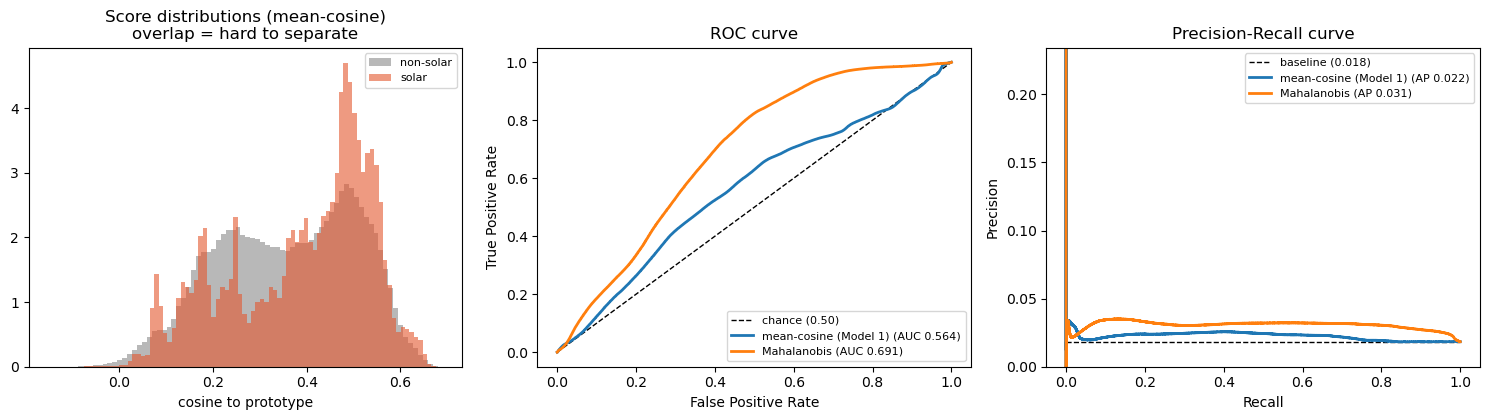

In [9]:
from sklearn.metrics import roc_curve, precision_recall_curve
base = ye.mean()
methods = {"mean-cosine (Model 1)": sc_cos, "Mahalanobis": sc_mah}
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))

ax[0].hist(sc_cos[ye==0], bins=80, density=True, alpha=.6, color="#8a8a8a", label="non-solar")
ax[0].hist(sc_cos[ye==1], bins=80, density=True, alpha=.6, color="#e4572e", label="solar")
ax[0].set_title("Score distributions (mean-cosine)\noverlap = hard to separate")
ax[0].set_xlabel("cosine to prototype"); ax[0].legend(fontsize=8)

ax[1].plot([0,1],[0,1],"k--",lw=1,label="chance (0.50)")
for n,s in methods.items():
    fpr,tpr,_=roc_curve(ye,s); ax[1].plot(fpr,tpr,lw=2,label=f"{n} (AUC {roc_auc_score(ye,s):.3f})")
ax[1].set_title("ROC curve"); ax[1].set_xlabel("False Positive Rate"); ax[1].set_ylabel("True Positive Rate"); ax[1].legend(fontsize=8)

ax[2].hlines(base,0,1,colors="k",linestyles="--",lw=1,label=f"baseline ({base:.3f})")
for n,s in methods.items():
    pr,rc,_=precision_recall_curve(ye,s); ax[2].plot(rc,pr,lw=2,label=f"{n} (AP {average_precision_score(ye,s):.3f})")
ax[2].set_title("Precision-Recall curve"); ax[2].set_xlabel("Recall"); ax[2].set_ylabel("Precision")
ax[2].set_ylim(0, min(0.35, base*10+0.05)); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 9. Suitability heatmaps

Finally, the intended product: apply the score to **every pixel** of a test tile to get a suitability heatmap, and compare
it to the true mask. If Model 1 worked, the bright regions would sit on top of the white mask. Watch what actually happens
— the scores track generic terrain (fields, ridges, roads), not the solar footprint. This is the visual version of the
near-chance numbers above, and it motivates §10.

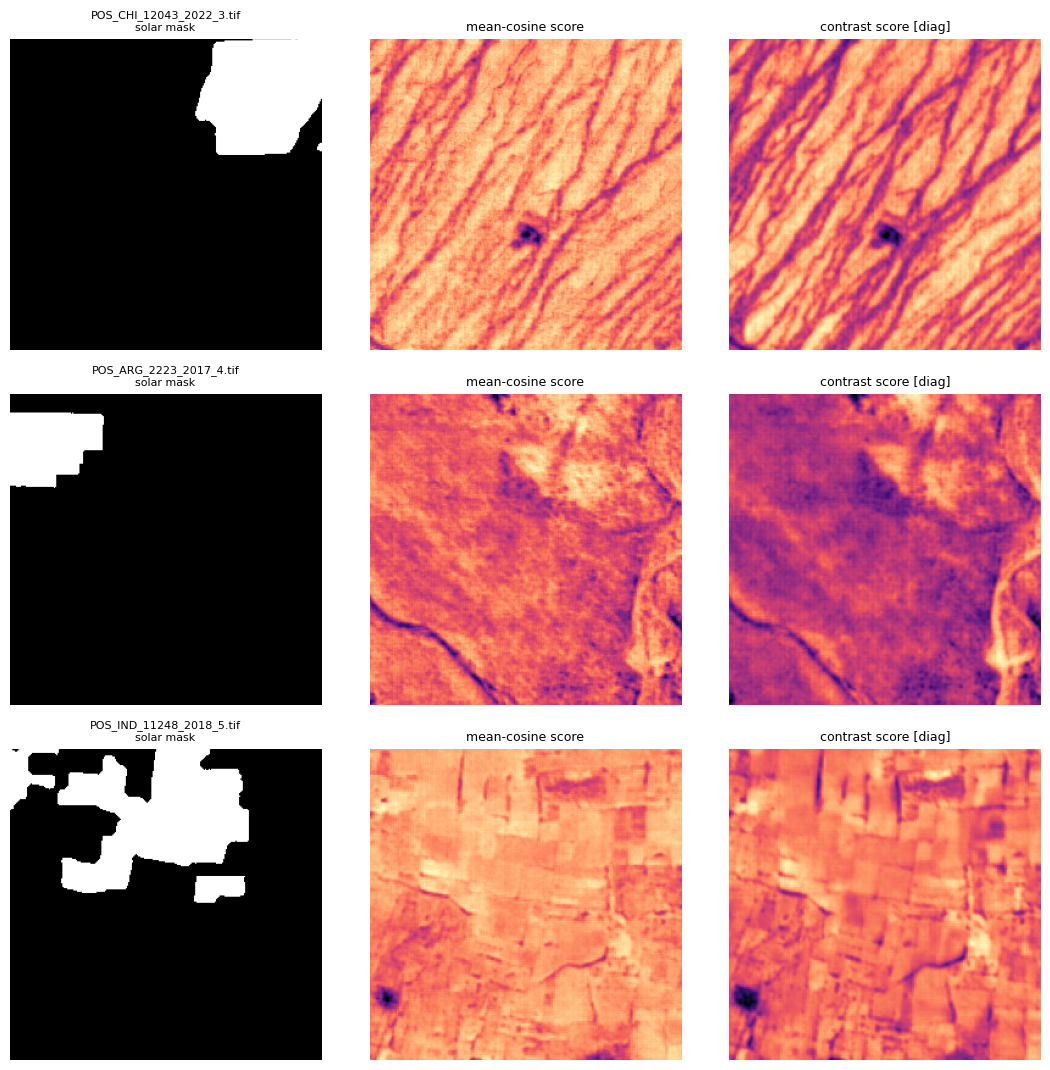

In [10]:
pc = mu - bmu; pc = pc / np.linalg.norm(pc)
picks = []
for fn in test_sub.chip:
    with rasterio.open(f"{MK}/{fn}") as m:
        if 0.05 < (m.read(1) > 0).mean() < 0.25: picks.append(fn)
    if len(picks) >= 3: break

fig, axs = plt.subplots(len(picks), 3, figsize=(11, 3.6*len(picks)))
for r, fn in enumerate(picks):
    with rasterio.open(f"{CH}/{fn}") as s: a = s.read().astype(np.float32)
    with rasterio.open(f"{MK}/{fn}") as m: mk = m.read(1)
    X = a.reshape(D, -1)
    axs[r,0].imshow(mk, cmap="gray");                            axs[r,0].set_title(f"{fn}\nsolar mask", fontsize=8)
    axs[r,1].imshow((proto@X).reshape(a.shape[1:]), cmap="magma");axs[r,1].set_title("mean-cosine score", fontsize=9)
    axs[r,2].imshow((pc@X).reshape(a.shape[1:]), cmap="magma");   axs[r,2].set_title("contrast score [diag]", fontsize=9)
    for c in range(3): axs[r,c].axis("off")
plt.tight_layout(); plt.show()

## 10. Findings & next steps

| Method | ROC-AUC | PR-AUC |
|---|---|---|
| **Mean-cosine (Model 1 as specified)** | **~0.57** | **~0.023** |
| k-means max-cos (K=4–32) | 0.41–0.54 | ≤0.020 |
| Mahalanobis (solar-cloud shape) | ~0.68 | ~0.030 |
| *within-chip contrast [diagnostic]* | *~0.80* | *~0.074* |
| baseline (guess prevalence) | 0.50 | ~0.018 |

**What we learned.**
1. **Mean-cosine similarity is near-chance** for locating solar pixels. The diagnostics say why:
   `cos(mean_solar, mean_background) ≈ 0.85` and mean resultant length `≈ 0.40` — pre-install solar-site land sits almost
   on top of its surroundings in AEF space; there is no distinct "solar cluster" to point a prototype at.
2. **More prototypes (k-means) made it worse** — the problem is *overlap*, not sub-types; max-cosine just lets background
   pixels find a nearby cluster.
3. **The only thing that helped was a *discriminative direction*** (solar − background). Proximity to a solar prototype
   fails; the *direction that separates* solar from not-solar works. Generative → discriminative is the takeaway.

**Caveat.** The 0.80 "contrast" uses in-scene background (context, not a true negative), and pooled per-pixel AUC partly
rewards which *scenes/regions* tend to have solar rather than the exact footprint. A proper suitability score needs
contrast against **true negatives** (globally-sampled land ≥5 km from any solar site).

**Recommended next step:** build a positive-vs-**true-negative** discriminative model (7,778 negatives already
downloaded) with a suitability evaluation where PR-AUC is meaningful. That is the pivotal test and the natural bridge to
**Model 2** (a per-pixel linear / MLP classifier, which *learns* the separating direction instead of hand-computing it).